# BTC Monte Carlo Simulation

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

np.random.seed(42)


DATA_PATH      = 'BTCUSDT_12h_ohlc.csv'
STEPS          = 90        # periods to simulate (90 × 12h = 45 days)
N_SIMS         = 2000     # number of Monte Carlo paths
CONFIDENCE     = [0.05, 0.25, 0.50, 0.75, 0.95]  # percentile bands
VAR_LEVEL      = 0.05      # 5% Value-at-Risk
PLOT_PATHS     = 200       # paths drawn on chart (visual clarity)

print('Config loaded.')

Config loaded.


## 1. Load & Inspect Historical Data

In [17]:
df = pl.read_csv(DATA_PATH, try_parse_dates=True)
df = df.sort('datetime')
print(f'Loaded {len(df):,} bars  |  {df["datetime"].min()}  →  {df["datetime"].max()}')
df.head(5)

Loaded 692 bars  |  2024-10-29 00:00:00  →  2025-10-09 12:00:00


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71440.1
2024-10-29 12:00:00,71440.0,73660.0,70900.0,72739.5
2024-10-30 00:00:00,72739.5,72797.4,71931.1,71995.0
2024-10-30 12:00:00,71994.9,72984.9,71444.2,72349.0
2024-10-31 00:00:00,72349.0,72720.3,72030.5,72213.3


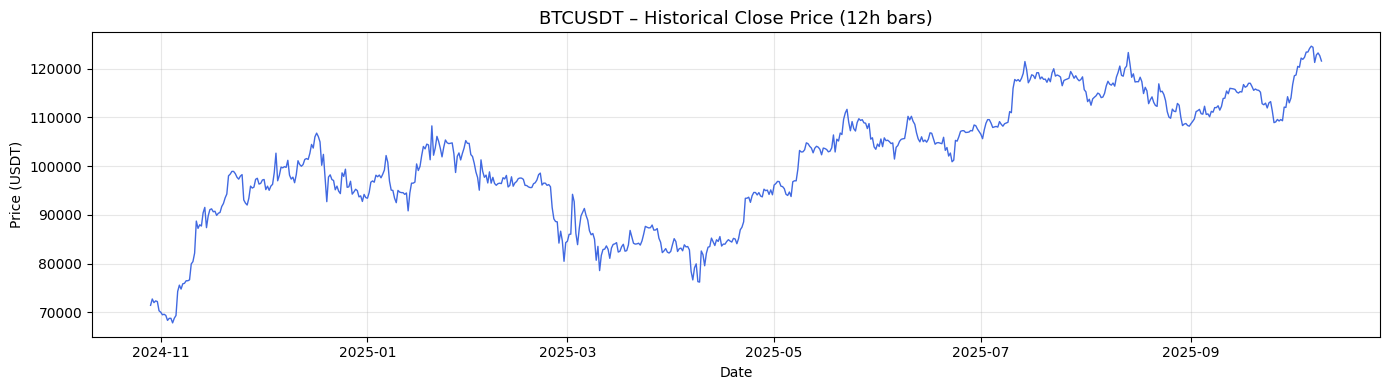

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['datetime'].to_list(), df['close'].to_list(), color='royalblue', linewidth=1)
ax.set_title('BTCUSDT – Historical Close Price (12h bars)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USDT)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Compute Log-Returns & Fit GBM Parameters

Under GBM the log-return per period follows:

$$\ln\!\left(\frac{S_{t+1}}{S_t}\right) \sim \mathcal{N}\!\left(\mu - \tfrac{\sigma^2}{2},\, \sigma^2\right)$$

Per-step   │ μ = 0.000769   σ = 0.017099
Annualised │ μ = 56.17%   σ = 46.20%


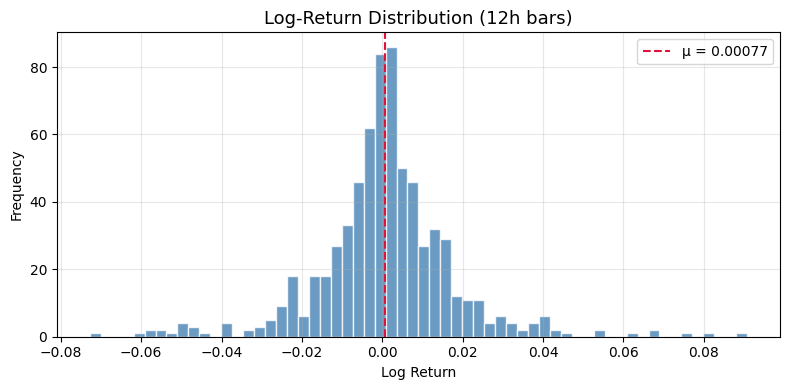

In [4]:
df = df.with_columns(
    (pl.col('close') / pl.col('close').shift(1)).log().alias('log_return')
).drop_nulls()

log_returns = df['log_return'].to_numpy()

mu_per_step    = float(log_returns.mean())      # mean log-return per 12-h bar
sigma_per_step = float(log_returns.std(ddof=1)) # std  log-return per 12-h bar

# Annualise (365 days × 2 bars/day = 730 bars/year)
bars_per_year = 730
mu_annual     = mu_per_step * bars_per_year
sigma_annual  = sigma_per_step * np.sqrt(bars_per_year)

print(f'Per-step   │ μ = {mu_per_step:.6f}   σ = {sigma_per_step:.6f}')
print(f'Annualised │ μ = {mu_annual:.2%}   σ = {sigma_annual:.2%}')

# Distribution of log-returns
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(log_returns, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(mu_per_step, color='crimson', linestyle='--', label=f'μ = {mu_per_step:.5f}')
ax.set_title('Log-Return Distribution (12h bars)', fontsize=13)
ax.set_xlabel('Log Return')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Monte Carlo Simulation

Each path is generated by sampling i.i.d. shocks:

$$S_{t+1} = S_t \cdot \exp\!\bigl(\mu\Delta t + \sigma\sqrt{\Delta t}\,Z_t\bigr), \quad Z_t \sim \mathcal{N}(0,1)$$

In [5]:
S0 = float(df['close'][-1])  # last known price
dt = 1.0                      # 1 step = 1 bar (12 h)

# GBM drift adjustment: (μ - σ²/2) per step
drift   = (mu_per_step - 0.5 * sigma_per_step**2) * dt
diffusion = sigma_per_step * np.sqrt(dt)

# Random shocks: shape (N_SIMS, STEPS)
Z = np.random.standard_normal((N_SIMS, STEPS))

# Cumulative log-returns
log_paths = np.cumsum(drift + diffusion * Z, axis=1)  # (N_SIMS, STEPS)

# Price paths: prepend S0 column
price_paths = S0 * np.exp(np.hstack([np.zeros((N_SIMS, 1)), log_paths]))  # (N_SIMS, STEPS+1)

print(f'Simulated {N_SIMS:,} paths × {STEPS} steps  |  S₀ = ${S0:,.2f}')
print(f'Simulation horizon: {STEPS * 0.5:.0f} days  ({STEPS} × 12h bars)')

Simulated 2,000 paths × 90 steps  |  S₀ = $121,579.30
Simulation horizon: 45 days  (90 × 12h bars)


## 4. Visualise Price Paths

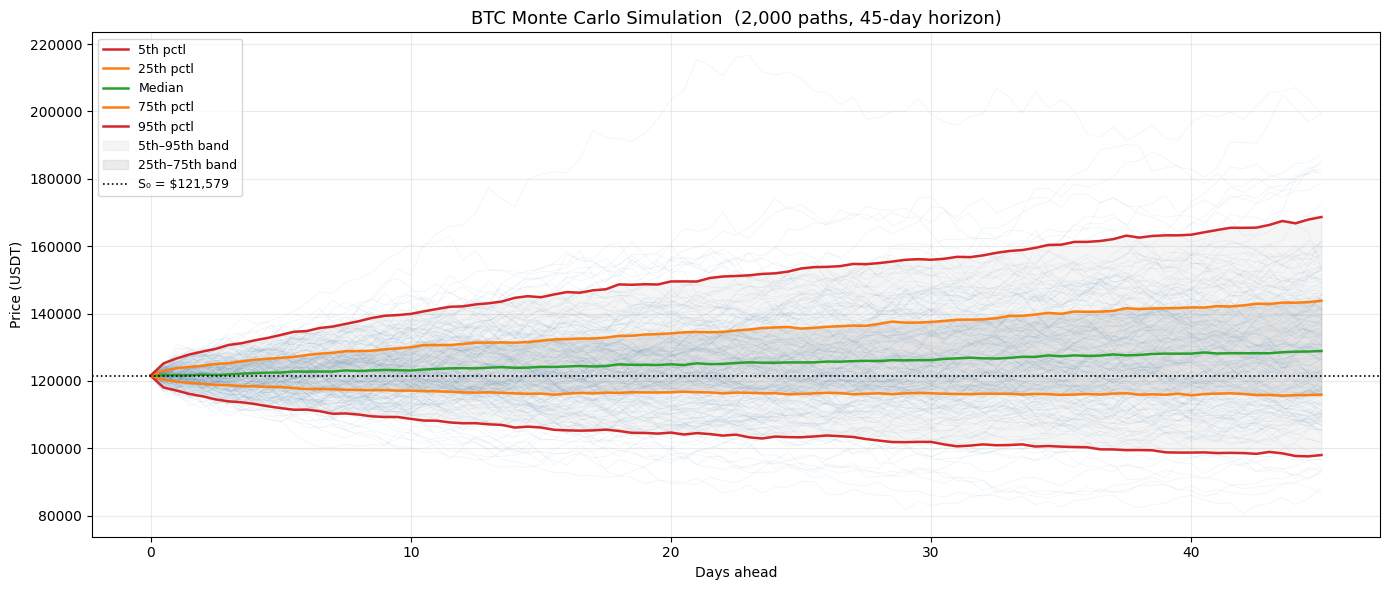

Saved: monte_carlo_paths.png


In [6]:
t = np.arange(STEPS + 1)  # time axis in bars
t_days = t * 0.5           # convert to days

percentiles = np.percentile(price_paths, [p * 100 for p in CONFIDENCE], axis=0)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot a random subset of paths
idx = np.random.choice(N_SIMS, size=min(PLOT_PATHS, N_SIMS), replace=False)
for i in idx:
    ax.plot(t_days, price_paths[i], color='steelblue', alpha=0.08, linewidth=0.6)

# Confidence bands
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#ff7f0e', '#d62728']
labels = ['5th pctl', '25th pctl', 'Median', '75th pctl', '95th pctl']
for pct, color, label in zip(percentiles, colors, labels):
    ax.plot(t_days, pct, color=color, linewidth=1.8, label=label)

# Fill between 5th and 95th
ax.fill_between(t_days, percentiles[0], percentiles[4], alpha=0.08, color='grey', label='5th–95th band')
ax.fill_between(t_days, percentiles[1], percentiles[3], alpha=0.15, color='grey', label='25th–75th band')

ax.axhline(S0, color='black', linestyle=':', linewidth=1.2, label=f'S₀ = ${S0:,.0f}')
ax.set_title(f'BTC Monte Carlo Simulation  ({N_SIMS:,} paths, {STEPS * 0.5:.0f}-day horizon)', fontsize=13)
ax.set_xlabel('Days ahead')
ax.set_ylabel('Price (USDT)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('monte_carlo_paths.png', dpi=150)
plt.show()
print('Saved: monte_carlo_paths.png')

## 5. Final-Price Distribution & Risk Metrics

In [7]:
final_prices = price_paths[:, -1]
final_returns = (final_prices - S0) / S0  # simple return vs S0

# ── Risk Metrics ──────────────────────────────────────────────────────────────
expected_price   = final_prices.mean()
median_price     = np.median(final_prices)
std_price        = final_prices.std()
prob_profit      = (final_prices > S0).mean()

# Value-at-Risk (VaR) at VAR_LEVEL confidence
var_price        = np.percentile(final_prices, VAR_LEVEL * 100)
var_loss_pct     = (var_price - S0) / S0

# Conditional VaR / Expected Shortfall
cvar_price       = final_prices[final_prices <= var_price].mean()
cvar_loss_pct    = (cvar_price - S0) / S0

pct_5, pct_25, pct_75, pct_95 = np.percentile(final_prices, [5, 25, 75, 95])

print('=' * 55)
print(f'  Simulation Horizon : {STEPS * 0.5:.0f} days')
print(f'  Starting Price S₀  : ${S0:>12,.2f}')
print('-' * 55)
print(f'  Expected Price     : ${expected_price:>12,.2f}  ({(expected_price/S0-1):+.2%})')
print(f'  Median Price       : ${median_price:>12,.2f}  ({(median_price/S0-1):+.2%})')
print(f'  Std Dev            : ${std_price:>12,.2f}')
print('-' * 55)
print(f'  5th  Percentile    : ${pct_5:>12,.2f}  ({(pct_5/S0-1):+.2%})')
print(f'  25th Percentile    : ${pct_25:>12,.2f}  ({(pct_25/S0-1):+.2%})')
print(f'  75th Percentile    : ${pct_75:>12,.2f}  ({(pct_75/S0-1):+.2%})')
print(f'  95th Percentile    : ${pct_95:>12,.2f}  ({(pct_95/S0-1):+.2%})')
print('-' * 55)
print(f'  Prob(Price > S₀)   : {prob_profit:.2%}')
print(f'  VaR  ({VAR_LEVEL:.0%})          : ${var_price:>12,.2f}  ({var_loss_pct:+.2%})')
print(f'  CVaR ({VAR_LEVEL:.0%})          : ${cvar_price:>12,.2f}  ({cvar_loss_pct:+.2%})')
print('=' * 55)

  Simulation Horizon : 45 days
  Starting Price S₀  : $  121,579.30
-------------------------------------------------------
  Expected Price     : $  130,677.18  (+7.48%)
  Median Price       : $  128,885.65  (+6.01%)
  Std Dev            : $   21,325.34
-------------------------------------------------------
  5th  Percentile    : $   98,014.80  (-19.38%)
  25th Percentile    : $  115,939.49  (-4.64%)
  75th Percentile    : $  143,806.02  (+18.28%)
  95th Percentile    : $  168,661.24  (+38.73%)
-------------------------------------------------------
  Prob(Price > S₀)   : 64.30%
  VaR  (5%)          : $   98,014.80  (-19.38%)
  CVaR (5%)          : $   91,785.82  (-24.51%)


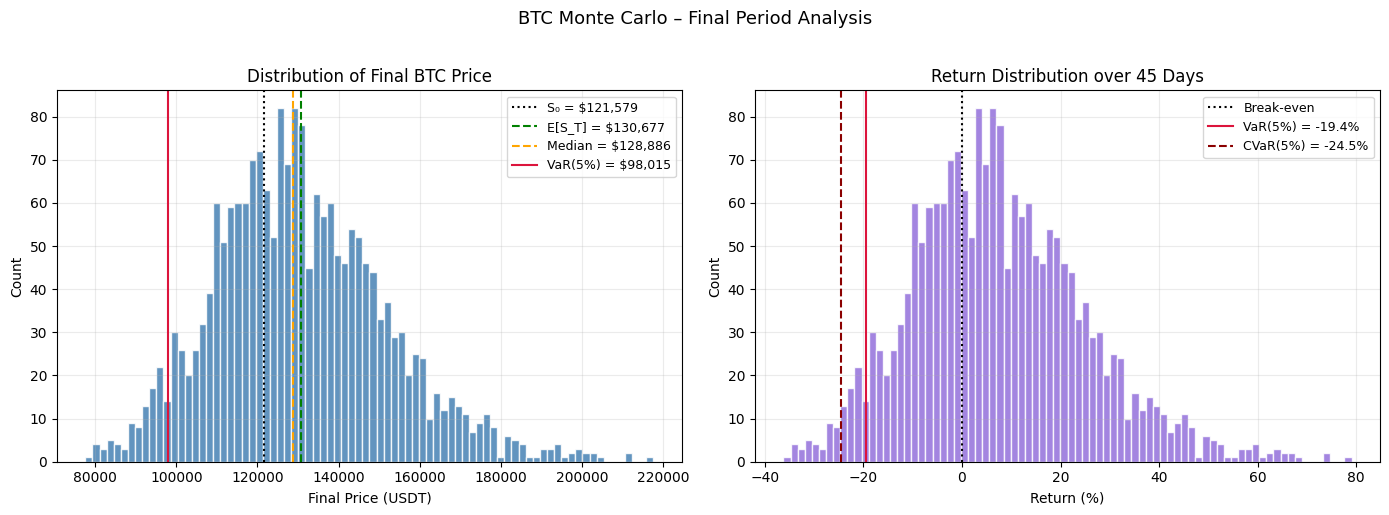

Saved: monte_carlo_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Final price histogram ────────────────────────────────────────────
ax = axes[0]
ax.hist(final_prices, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(S0,             color='black',  linestyle=':',  linewidth=1.5, label=f'S₀ = ${S0:,.0f}')
ax.axvline(expected_price, color='green',  linestyle='--', linewidth=1.5, label=f'E[S_T] = ${expected_price:,.0f}')
ax.axvline(median_price,   color='orange', linestyle='--', linewidth=1.5, label=f'Median = ${median_price:,.0f}')
ax.axvline(var_price,      color='crimson',linestyle='-',  linewidth=1.5, label=f'VaR(5%) = ${var_price:,.0f}')
ax.set_title('Distribution of Final BTC Price', fontsize=12)
ax.set_xlabel('Final Price (USDT)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# ── Right: Return distribution ─────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(final_returns * 100, bins=80, color='mediumpurple', edgecolor='white', alpha=0.85)
ax2.axvline(0,                         color='black',  linestyle=':',  linewidth=1.5, label='Break-even')
ax2.axvline(var_loss_pct * 100,        color='crimson',linestyle='-',  linewidth=1.5, label=f'VaR(5%) = {var_loss_pct:.1%}')
ax2.axvline(cvar_loss_pct * 100,       color='darkred',linestyle='--', linewidth=1.5, label=f'CVaR(5%) = {cvar_loss_pct:.1%}')
ax2.set_title(f'Return Distribution over {STEPS * 0.5:.0f} Days', fontsize=12)
ax2.set_xlabel('Return (%)')
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

plt.suptitle('BTC Monte Carlo – Final Period Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('monte_carlo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: monte_carlo_distribution.png')

## 6. Percentile Fan Chart (Summary)

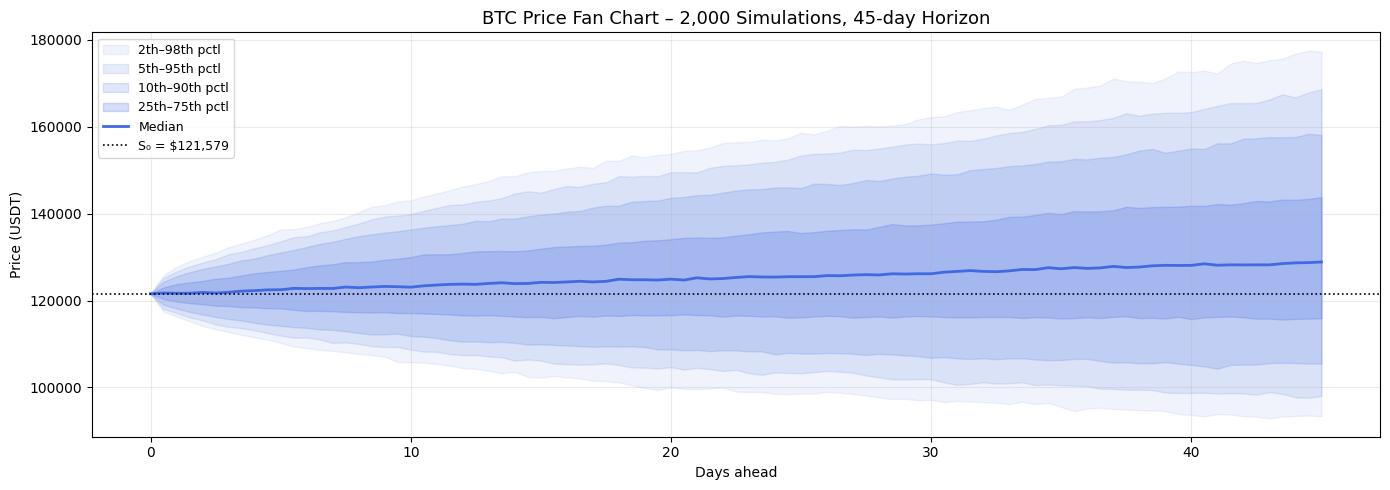

Saved: monte_carlo_fan.png


In [9]:
bands = [
    (2.5, 97.5, 0.08),
    (5,   95,   0.12),
    (10,  90,   0.16),
    (25,  75,   0.22),
]

fig, ax = plt.subplots(figsize=(14, 5))

for lo, hi, alpha in bands:
    p_lo = np.percentile(price_paths, lo, axis=0)
    p_hi = np.percentile(price_paths, hi, axis=0)
    ax.fill_between(t_days, p_lo, p_hi, alpha=alpha, color='royalblue',
                    label=f'{lo:.0f}th–{hi:.0f}th pctl')

# Median
median_path = np.median(price_paths, axis=0)
ax.plot(t_days, median_path, color='royalblue', linewidth=2, label='Median')
ax.axhline(S0, color='black', linestyle=':', linewidth=1.2, label=f'S₀ = ${S0:,.0f}')

ax.set_title(f'BTC Price Fan Chart – {N_SIMS:,} Simulations, {STEPS * 0.5:.0f}-day Horizon', fontsize=13)
ax.set_xlabel('Days ahead')
ax.set_ylabel('Price (USDT)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('monte_carlo_fan.png', dpi=150)
plt.show()
print('Saved: monte_carlo_fan.png')

## 7. Interactive: Change Horizon

Re-run the simulation with a custom number of steps.

In [10]:
def run_monte_carlo(
    S0: float,
    mu: float,
    sigma: float,
    steps: int,
    n_sims: int = 2_000,
    seed: int = 42,
) -> np.ndarray:
    """
    Simulate GBM price paths.

    Parameters
    ----------
    S0     : starting price
    mu     : per-step mean log-return
    sigma  : per-step std of log-return
    steps  : number of future bars to simulate
    n_sims : number of Monte Carlo paths
    seed   : random seed

    Returns
    -------
    price_paths : np.ndarray of shape (n_sims, steps + 1)
    """
    rng = np.random.default_rng(seed)
    drift     = (mu - 0.5 * sigma**2)
    Z         = rng.standard_normal((n_sims, steps))
    log_paths = np.cumsum(drift + sigma * Z, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_sims, 1)), log_paths]))


def summarise(paths: np.ndarray, S0: float, bar_size_hours: float = 12):
    """Print risk summary for a set of simulated paths."""
    fp     = paths[:, -1]
    steps  = paths.shape[1] - 1
    days   = steps * bar_size_hours / 24
    var5   = np.percentile(fp, 5)
    cvar5  = fp[fp <= var5].mean()
    print(f'Horizon: {days:.0f} days  |  S₀ = ${S0:,.2f}')
    print(f'  E[S_T]   = ${fp.mean():>12,.2f}  ({fp.mean()/S0-1:+.2%})')
    print(f'  Median   = ${np.median(fp):>12,.2f}  ({np.median(fp)/S0-1:+.2%})')
    print(f'  P(>S₀)   = {(fp > S0).mean():.2%}')
    print(f'  VaR  5%  = ${var5:>12,.2f}  ({var5/S0-1:+.2%})')
    print(f'  CVaR 5%  = ${cvar5:>12,.2f}  ({cvar5/S0-1:+.2%})')


# --- Example: 90-day horizon (180 × 12h bars) ---
paths_90d = run_monte_carlo(S0, mu_per_step, sigma_per_step, steps=180, n_sims=2000)
summarise(paths_90d, S0)

Horizon: 90 days  |  S₀ = $121,579.30
  E[S_T]   = $  139,573.79  (+14.80%)
  Median   = $  136,073.63  (+11.92%)
  P(>S₀)   = 68.55%
  VaR  5%  = $   93,770.08  (-22.87%)
  CVaR 5%  = $   86,312.57  (-29.01%)
